# 💨 Air Quality & Greenhouse Gas Plumes
## Arab 813 Hackathon — Planet Tanager Hyperspectral Explorer

This notebook explores **Planet's Tanager GHG-plumes collection**, where the satellite has flagged scenes with methane (CH₄) or CO₂ point-source emission detections.

---

## What You Will Learn

- What a greenhouse gas plume is and how satellites detect it
- How to access the GHG-plumes STAC collection
- How to visualize spectral absorption features at methane-sensitive wavelengths
- How to compute proxy indices around the 2300 nm methane absorption window

---

## How Does Tanager Detect Methane?

Methane absorbs sunlight at specific wavelengths — particularly around **2,300 nm** in the shortwave infrared (SWIR). Tanager's 426 spectral bands span this region with ~5 nm resolution.

When methane is present in the air column above a site, those wavelengths appear **darker** compared to their neighbors. By comparing the radiance at absorption wavelengths versus adjacent "window" wavelengths, Carbon Mapper's algorithms can detect and quantify individual plumes.

> The GHG-plume collection contains scenes where this algorithm **detected a plume**. The scene may contain a plume over an oil field, pipeline, landfill, or agricultural facility.

---

## Relevant STAC Collection

```
https://www.planet.com/data/stac/tanager-core-imagery/GHG-plumes/collection.json
```


In [1]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

## Step 1 – Load Items from the GHG-Plumes Collection

> 💡 Browse available scenes at:
> https://www.planet.com/data/stac/browser/tanager-core-imagery/GHG-plumes/collection.json


In [3]:
import requests

COLLECTION = "GHG-plumes"
# Browse the collection.json to find item IDs:
# https://www.planet.com/data/stac/tanager-core-imagery/GHG-plumes/collection.json
col_url = f"https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}/collection.json"
col = requests.get(col_url, timeout=60).json()

# Extract all item links
item_links = [l for l in col.get("links", []) if l.get("rel") == "item"]
print(f"Found {len(item_links)} scenes in {COLLECTION}")
for lnk in item_links[:10]:
    print(" ", lnk["href"].split("/")[-1].replace(".json",""))

/Users/vincentmarkiet/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 8 scenes in GHG-plumes
  20241004_081921_28_4001
  20250226_065447_19_4001
  20241121_183741_33_4001
  20250219_053251_31_4001
  20250423_134021_00_4001
  20250423_134026_31_4001
  20250114_062056_92_4001
  20250703_063928_86_4001


## Step 2 – Load the First Scene


In [33]:
# Load the first available item
item_url = item_links[3]["href"]
item = requests.get(item_url, timeout=60).json()
item = requests.get(item_url, timeout=60).json()

print("ID  :", item["id"])
print("Date:", item["properties"]["datetime"])
print("Bbox:", item["bbox"])
print("Assets:", list(item["assets"].keys()))

ID  : 20250219_053251_31_4001
Date: 2025-02-19T05:32:51.310080Z
Bbox: [82.54368810046248, 22.231597952731466, 82.78234878328922, 22.493381707878495]
Assets: ['basic_beta_udm', 'basic_radiance_hdf5', 'basic_sr_hdf5', 'geolocation_array', 'ortho_beta_udm', 'ortho_ql_ch4', 'ortho_radiance_hdf5', 'ortho_sr_hdf5', 'ortho_visual', 'ql_ch4_json', 'recent_monthly_mosaic', 'thumbnail']


## Step 3 – Thumbnail & Metadata


In [34]:
from IPython.display import Image
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])
Image(url=item["assets"]["thumbnail"]["href"])

Scene ID: 20250219_053251_31_4001
Date    : 2025-02-19T05:32:51.310080Z
Bbox    : [82.54368810046248, 22.231597952731466, 82.78234878328922, 22.493381707878495]


In [35]:
import json
print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 0,
  "collection_mode": "standard_sensitivity",
  "constellation": "Tanager",
  "datetime": "2025-02-19T05:32:51.310080Z",
  "description": "All data products from Tanager-1 for 20250219_053251_31_4001 near Kusmunda, Katghora Tahsil, Korba, Chhattisgarh, 495454, India",
  "gsd": 36.01,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 0,
  "location_description": "Kusmunda, Katghora Tahsil, Korba, Chhattisgarh, 495454, India",
  "notes": "No methane plumes detected, but there is a CO2 plume present in this collect",
  "platform": "Planet",
  "plume_provider_ids": [
    "tan20250219t053246c00s4001-A",
    "tan20250219t053246c00s4001-B",
    "tan20250219t053246c00s4001-C",
    "tan20250219t053246c00s4001-D",
    "tan20250219t053246c00s4001-E",
    "tan20250219t053246c00s4001-F"
  ],
  "quality_category": "standard",
  "title": "TanagerScene 20250219_053251_31_4001 Core Imagery",
  "view:azimuth": 319.9,
  "view:off_nadir": 0.2,
  "v

## Step 4 – Interactive Map


In [36]:
import leafmap, geopandas as gpd
from shapely.geometry import box

m = leafmap.Map(zoom=8)
ib = item["bbox"]
m.fit_bounds([[ib[1], ib[0]], [ib[3], ib[2]]])

# Scene footprint
gdf = gpd.GeoDataFrame({"geometry": [box(*ib)]}, crs="EPSG:4326")
m.add_gdf(gdf, layer_name="Scene footprint", style={"color":"yellow","fillOpacity":0})

# Visual COG overlay
for vk in ["ortho_visual", "visual", "rendered_preview"]:
    if vk in item.get("assets", {}):
        m.add_cog_layer(item["assets"][vk]["href"],
                        name=item["id"]+" (visual)",
                        titiler_endpoint="https://titiler.xyz")
        break

m

Map(center=[82.66312397930534, 22.362534343465192], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## Step 5 – Download the Surface Reflectance HDF5

We download the full surface reflectance cube to examine the methane absorption spectral region.


In [37]:
import os, requests

sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR asset:", sr_key)
print("URL:", sr_url)

local_path = os.path.basename(sr_url)
if not os.path.exists(local_path):
    print("Downloading… (may take a few minutes)")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as fout:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    fout.write(chunk)
    print("Saved to:", local_path)
else:
    print("Already downloaded:", local_path)

Using SR asset: ortho_sr_hdf5
URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250219_053251_31_4001_ortho_sr_hdf5.h5
Downloading… (may take a few minutes)
Saved to: 20250219_053251_31_4001_ortho_sr_hdf5.h5


## Step 6 – Scene Quality Check


In [38]:
import h5py, numpy as np

root = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(local_path, "r") as f:
    cloud  = f[f"{root}/beta_cloud_mask"][:]
    nodata = f[f"{root}/nodata_pixels"][:]
    cirrus = f[f"{root}/beta_cirrus_mask"][:]

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0)
print(f"Valid pixels: {valid.mean()*100:.1f}%")
print(f"Cloud cover:  {(cloud!=0).mean()*100:.1f}%")

Valid pixels: 72.7%
Cloud cover:  0.0%


## Step 7 – Extract Spectral Wavelengths


In [39]:
# Extract spectral wavelengths from STAC metadata.
# The key is "bands" and wavelengths are in micrometers under "eo:center_wavelength".
bands_meta = item["assets"][sr_key].get("bands", [])
spectral_bands = [b for b in bands_meta if "eo:center_wavelength" in b]
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0   # micrometers -> nanometers

print("Number of spectral bands:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last  10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last  10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


## Step 8 – Examine the Methane Absorption Window

Methane has strong absorption features around:
- **2,300 – 2,380 nm** (strong SWIR absorption)
- **1,660 – 1,750 nm** (weaker, often masked by water vapor)

We'll focus on the 2,300 nm window and compute a simple **MBSI** (Methane Band Suppression Index):

`MBSI = (R_ref1 + R_ref2) / (2 × R_abs) - 1`

where `R_abs` is reflectance inside the absorption band and `R_ref` are reference bands on either side.
A positive MBSI → the absorption wavelength is suppressed → possible methane presence.


In [40]:
import numpy as np
def pick_band(target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    print(f"  Target {target_nm} nm → band {idx} ({wavelengths_nm[idx]:.1f} nm)")
    return idx, wavelengths_nm[idx]

print("Methane-sensitive bands:")
idx_ref1, _ = pick_band(2250)   # reference band (before absorption)
idx_abs1, _ = pick_band(2305)   # inside CH4 absorption
idx_abs2, _ = pick_band(2345)   # inside CH4 absorption
idx_ref2, _ = pick_band(2380)   # reference band (after absorption)

# Additional bands for context
idx_nir,  _ = pick_band(860)
idx_swir, _ = pick_band(1640)

Methane-sensitive bands:
  Target 2250 nm → band 375 (2250.9 nm)
  Target 2305 nm → band 386 (2305.6 nm)
  Target 2345 nm → band 394 (2345.3 nm)
  Target 2380 nm → band 401 (2380.0 nm)
  Target 860 nm → band 97 (861.3 nm)
  Target 1640 nm → band 252 (1637.7 nm)


In [41]:
import h5py

root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    R_ref1 = sr[idx_ref1, :, :].astype("float32")
    R_abs1 = sr[idx_abs1, :, :].astype("float32")
    R_abs2 = sr[idx_abs2, :, :].astype("float32")
    R_ref2 = sr[idx_ref2, :, :].astype("float32")
    R_nir  = sr[idx_nir,  :, :].astype("float32")
    R_swir = sr[idx_swir, :, :].astype("float32")

for arr in [R_ref1, R_abs1, R_abs2, R_ref2, R_nir, R_swir]:
    arr[~valid] = np.nan
    arr[arr < 0] = np.nan

## Step 9 – Compute green house gas related indices


In [42]:
eps = 1e-6

# Methane Band Suppression Index (simple proxy)
R_abs = (R_abs1 + R_abs2) / 2
MBSI = (R_ref1 + R_ref2) / (2 * R_abs + eps) - 1

# NDSI-SWIR: contrast between different SWIR windows (surface mineralogy context)
NDSI_SWIR = (R_swir - R_nir) / (R_swir + R_nir + eps)

# Plume enhancement proxy: normalized anomaly in absorption window
# High values = absorption stronger than expected = possible plume
ref_mean = (R_ref1 + R_ref2) / 2
plume_proxy = (ref_mean - R_abs) / (ref_mean + eps)

## Step 10 – Visualize


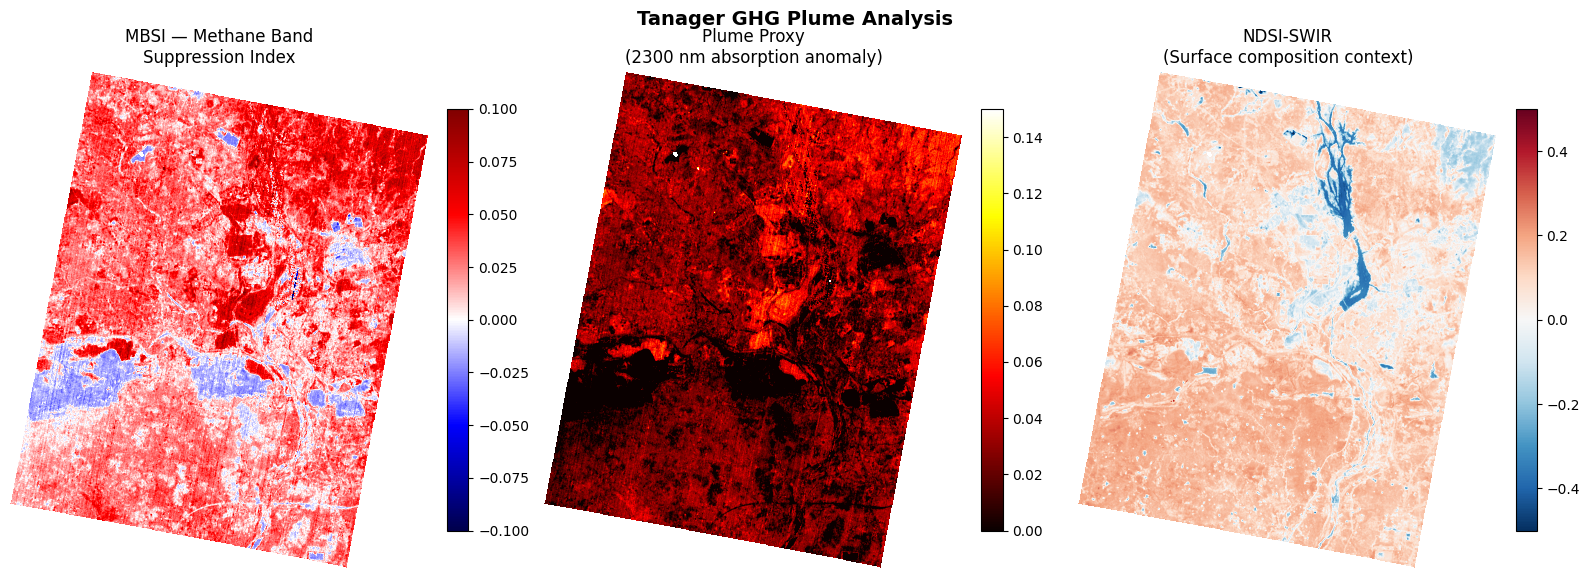

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

im1 = axes[0].imshow(MBSI, cmap="seismic", vmin=-0.1, vmax=0.1)
axes[0].set_title("MBSI — Methane Band\nSuppression Index"); axes[0].axis("off")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(plume_proxy, cmap="hot", vmin=0, vmax=0.15)
axes[1].set_title("Plume Proxy\n(2300 nm absorption anomaly)"); axes[1].axis("off")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

im3 = axes[2].imshow(NDSI_SWIR, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[2].set_title("NDSI-SWIR\n(Surface composition context)"); axes[2].axis("off")
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle("Tanager GHG Plume Analysis", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 11 – Spectrum at the Methane Window

This plot shows the full spectrum averaged across the scene, zoomed into the SWIR region.
A healthy surface shows relatively smooth reflectance. A plume appears as an anomalous dip.


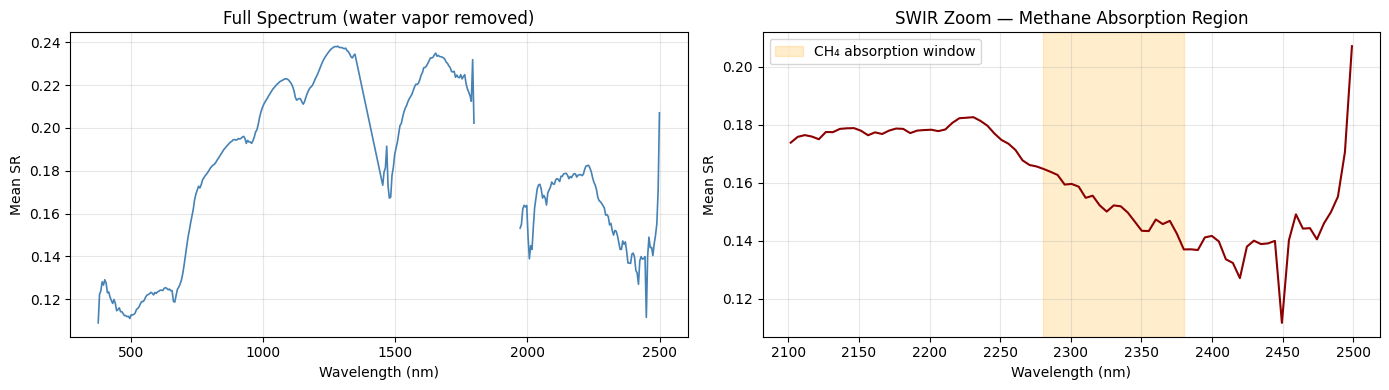

In [44]:
import h5py

stride = 8
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
    cube = sr[good_idx, ::stride, ::stride].astype("float32")
    mask = valid[::stride, ::stride]
    cube[:, ~mask] = np.nan
    cube[cube < 0] = np.nan
    mean_spec = np.nanmean(cube, axis=(1,2))

wls = [wavelengths_nm[i] for i in good_idx]

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(wls, mean_spec, lw=1.2, color="steelblue")
ax1.set_xlabel("Wavelength (nm)"); ax1.set_ylabel("Mean SR")
ax1.set_title("Full Spectrum (water vapor removed)"); ax1.grid(alpha=0.3)

# Zoom into SWIR methane window
swir_mask = [(w >= 2100 and w <= 2500) for w in wls]
wls_swir = [w for w, m in zip(wls, swir_mask) if m]
spec_swir = [s for s, m in zip(mean_spec, swir_mask) if m]
ax2.plot(wls_swir, spec_swir, lw=1.5, color="darkred")
ax2.axvspan(2280, 2380, alpha=0.2, color="orange", label="CH₄ absorption window")
ax2.set_xlabel("Wavelength (nm)"); ax2.set_ylabel("Mean SR")
ax2.set_title("SWIR Zoom — Methane Absorption Region")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 🚀 Hackathon Challenge Ideas

- **Plume localization** — threshold the `plume_proxy` map to identify the highest-anomaly pixels. Do they align with known infrastructure?
- **Multi-scene comparison** — compare the spectral signature at the plume location vs background pixels
- **Emission source attribution** — overlay with OpenStreetMap infrastructure data to identify likely emitting facilities
- **MBSI temporal analysis** — load multiple GHG-plume scenes over the same area and track whether the signal persists

> 📖 Created by: [LInkedin: Dr. Vincent Markiet - Space42](https://www.linkedin.com/in/vincentmarkiet/) 

> 📖 Data license: CC-BY-4.0 © Planet Labs PBC

> Carbon Mapper methane detection methodology: doi:10.5194/amt-8-4383-2015
